## 신경망 학습

#### 손실 함수
* 신경망 서능의 나쁨을 나타내는 지표, 현재의 신경망이 훈련 데이터를 얼마나 잘 처리하지 못하는지를 나타냄

#### 평균 제곱 오차
$$
\mathrm{MSE} = \frac{1}{2} \sum_{k} (y_k - t_k)^2
$$
* $y_k$: 신경망의 출력
* $t_k$: 정답 레이블
* k: 데이터의 차원 수

In [1]:
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

* 원-핫 인코딩: 한 원소만 1로 하고 그 외는 0으로 나타내는 표기법

In [6]:
def mean_squared_error(y, t):
    return 0.5 * np.sum((y - t) ** 2)

In [8]:
# 정답은 2
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

# '2'일 확률이 가장 높다고 추정
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

print(mean_squared_error(np.array(y), np.array(t)))

0.09750000000000003


* 오차가 작을수록 정답에 더 가까움

#### 교차 엔트로피 오차
$$
E = - \sum_{k} t_k \log y_k
$$

In [3]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

* delta를 더해 log 함수에 0이 들어가 마이너스 무한대가 되지 않도록 방지

In [5]:
# 정답은 2
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

# '2'일 확률이 가장 높다고 추정
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

print(cross_entropy_error(np.array(y), np.array(t)))

0.510825457099338


#### 미니배치 학습
$$
E = -\frac{1}{N}\sum_{n}\sum_{k} t_{nk} \log y_{nk}
$$
* 빅데이터면 시간이 오래 걸리기 때문에 일부를 통해 근사치를 이용함 -> 미니배치

In [6]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


In [7]:
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

print(x_batch.shape)
print(t_batch.shape)

(10, 784)
(10, 10)


In [8]:
print(np.random.choice(60000, 10))

[35587 57390 21202 36186  5175  7384 33199  1722 34362 23212]


In [9]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y)) / batch_size

In [10]:
# 정답 레이블이 원-핫 인코딩이 아닌 경우
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y[np.arange(batch_size), t])) / batch_size

* 예를 들어 np.arange(batch_size)가 [0, 1, 2, 3, 4]라는 넘파이 배열을 생성한다고 가정
    * y[np.arange(batch_size), t]는 각 데이터의 정답 레이블에 해당하는 신경망의 출력을 추출
    * [y[0, 2], y[1, 7], y[2, 0], y[3, 9], y[4, 4]]를 생성

#### 손실 함수를 사용하는 이유
* 최적의 매개변수를 탐색할 때 손실 함수의 값을 가능한 작게 하는 매개변수 값을 찾음
* 매개변수의 미분을 계산하고 그 값을 단서로 서서히 갱신하는 과정을 반복
* 정확도를 지표로 삼아서는 안되는 이유는 미분 값이 대부분의 장소에서 0이 되어 매개변수를 갱신할 수 없기 때문

### 수치 미분

In [11]:
# 미분의 나쁜 구현
def numerical_diff(f, x):
    h = 10e-50
    return (f(x + h) - f(x)) / h

* h에 10e-50을 이용해 작은 값을 이용했으나 반올림 오차의 문제를 일으킴
    * 반올림 오차: 작은 값이 생략되어 최종 결과 계산에 오차가 생기게 함
* f의 차분을 계산하는 것이지 진정한 미분을 계산하는 것이 아님
    * 차분: 임의의 두 점에서의 함수 값들의 차이
    * 이 오차를 줄이기 위해 x를 중심으로 그 전후의 차분을 계산, 위 계산은 전방 차분임

In [12]:
# 반올림 오차 예시
print(np.float32(1e-50))

0.0


In [14]:
# 개선
def numerical_diff(f, x):
    h = 1e-4
    return (f(x + h) - f(x - h)) / (2 * h)

In [15]:
# 예시
# y = 0.01x^2 + 0.1x
def function_1(x):
    return 0.01 * x ** 2 + 0.1 * x

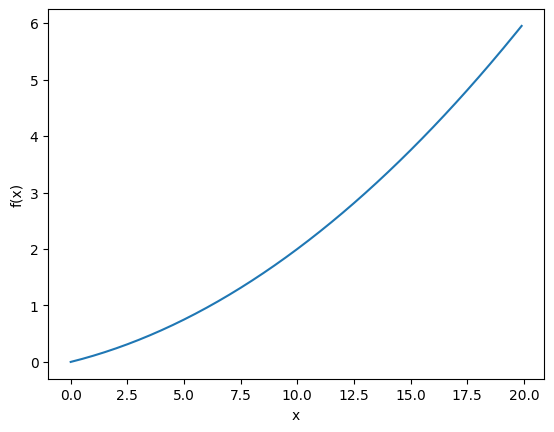

In [16]:
# 시각화
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

In [17]:
print(numerical_diff(function_1, 5))
print(numerical_diff(function_1, 10))

0.1999999999990898
0.2999999999986347


#### 편미분

예시
$$
f(x_0, x_1) = {x_0}^2 + {x_1}^2
$$

In [20]:
def function_2(x):
    return x[0] ** 2 + x[1] ** 2
    # 또는 return np.sum(x ** 2)

In [30]:
# x0에 대한 편미분
def function_tmp1(x0):
    return x0 * x0 + 4.0 ** 2.0

print(numerical_diff(function_tmp1, 3.0))

6.00000000000378


In [31]:
# x1에 대한 편미분
def function_tmp2(x1):
    return 3.0 ** 2.0 + x1 * x1

print(numerical_diff(function_tmp2, 4.0))

7.999999999999119


### 기울기

* 모든 변수의 편미분을 벡터로 정리한 것

In [67]:
# 예시
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x) # x와 형상이 같은 배열 생성

    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x + h) 계산
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x - h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / 2 * h
        x[idx] = tmp_val # 값 복원

    return grad

In [34]:
print(numerical_gradient(function_2, np.array([3.0, 4.0])))
print(numerical_gradient(function_2, np.array([0.0, 2.0])))
print(numerical_gradient(function_2, np.array([3.0, 0.0])))

[6.e-08 8.e-08]
[0.e+00 4.e-08]
[6.e-08 0.e+00]


* 기울기가 가리키는 쪽은 각 장소에서 함수의 출력 값을 가장 줄이는 방향

#### 경사하강법
* 기계학습 문제 대부분은 학습 단계에서 최적의 매개변수를 찾음
* 신경망도 매개변수(가중치와 편향)을 학습 시 찾아야 함
* 최적이란 손실 함수가 최솟값이 될 때의 매개변수 값
* 경사하강법: 기울기를 이용해 함수의 최솟값을 찾으려는 것
    * 기울어진 방향이 꼭 최솟값을 가리키는 것은 아니나, 그 방향으로 가야 함수의 값을 줄일 수 있음
    * 현 위치에서 기울어진 방향으로 일정 거리를 이동, 기울기를 구한 후 이동, 반복

$$
\begin{aligned}
x_0 = x_0 - \eta \frac{\partial f}{\partial x_0} \\
x_1 = x_1 - \eta \frac{\partial f}{\partial x_1}
\end{aligned}
$$
* 위 수식은 갱신하는 양을 나타내면 학습률이라 함
* 일반적으로 미리 특정 값으로 정해두는데 너무 크거나 작으면 좋은 장소를 찾을 수 없음

In [68]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x

    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x

In [69]:
# 경사하강법으로 최솟값 구하기
def function_2(x):
    return x[0] ** 2 + x[1] ** 2

init_x = np.array([-3.0, 4.0])
print(gradient_descent(function_2, init_x=init_x, lr=0.1, step_num=100))

[-2.9999994  3.9999992]


In [70]:
# 학습률이 너무 클 때: lr=10.0
init_x = np.array([-3.0, 4.0])
print(gradient_descent(function_2, init_x=init_x, lr=10.0, step_num=100))

# 학습률이 너무 작을 때: lr=1e-10
init_x = np.array([-3.0, 4.0])
print(gradient_descent(function_2, init_x=init_x, lr=1e-10, step_num=100))

[-2.99994  3.99992]
[-3.  4.]


#### 신경망에서의 기울기
$$
W = 
\begin{pmatrix}
w_{11} & w_{21} & w_{31} \\
w_{12} & w_{22} & w_{32}
\end{pmatrix}
$$
$$
\frac{\partial L}{\partial W} =
\begin{pmatrix}
\frac{\partial L}{\partial w_{11}} & \frac{\partial L}{\partial w_{21}} & \frac{\partial L}{\partial w_{31}} \\
\frac{\partial L}{\partial w_{12}} & \frac{\partial L}{\partial w_{22}} & \frac{\partial L}{\partial w_{32}}
\end{pmatrix}
$$

In [74]:
# 실제 기울기를 구하는 코드
import sys, os
sys.path.append(os.pardir)
import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient

class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2, 3)

    def predict(self, x):
        return np.dot(x, self.W)
    
    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

In [83]:
net = simpleNet()
print(net.W)

x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

print(np.argmax(p))

t = np.array([0, 0, 1])
print(net.loss(x, t))

[[ 0.10471771 -0.3920971  -1.04804584]
 [-0.80332244  1.65507989 -0.18687265]]
[-0.66015957  1.25431365 -0.79701289]
1
2.295042960886391


In [90]:
def f(W):
    return net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.06932032  0.47022497 -0.53954529]
 [ 0.10398047  0.70533745 -0.80931793]]


In [92]:
f = lambda w: net.loss(x, t)
dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.06932032  0.47022497 -0.53954529]
 [ 0.10398047  0.70533745 -0.80931793]]


### 학습 알고리즘 구현
* 전제
    * 신경망에는 적응 가능한 가중치와 편향이 있고, 이 가중치와 편향을 훈련 데이터에 적용하도록 조정하는 과정을 '학습'이라 함
    * 4단계로 학습
1. 미니배치
    * 훈련 데이터 중 일부를 무작위로 가져옴
    * 미니배치의 손실 함수 값을 줄이는 것을 목표로 함
2. 기울기 산출
    * 미니배치의 손실 함수 값을 줄이기 위해 각 가중치 매개변수의 기울기를 구함
3. 매개변수 갱신
    * 가중치 매개변수를 기울기 방향으로 아주 조금 갱신
4. 반복
    * 1~3단계를 반복

* 데이터를 미니배치로 무작위로 선정하기 때문에 확률적 경사 하강법(SGD)라 부름

In [93]:
import sys, os
sys.path.append(os.pardir)
from common.functions import *
from common.gradient import numerical_gradient

class TwoLayerNet:
    def __init__(self, input_size, hidden_size,
                 output_size, weight_init_std=0.01):
        # 가중치 초기회
        self.params = {}
        self.params['W1'] = weight_init_std * \
                                np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * \
                                np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y
    
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads

In [95]:
net = TwoLayerNet(input_size=784, hidden_size=100, output_size=10)
print(net.params['W1'].shape)
print(net.params['b1'].shape)
print(net.params['W2'].shape)
print(net.params['b2'].shape)

(784, 100)
(100,)
(100, 10)
(10,)


In [ ]:
x = np.random.rand(100, 784) # 더미 입력 데이터(100장 분량)
y = net.predict(x)

In [99]:
x = np.random.rand(100, 784) # 더미 입력 데이터(100장 분량)
t = np.random.rand(100, 10) # 더미 입력 데이터(100장 분량)

grads = net.numerical_gradient(x, t)

print(grads['W1'].shape)
print(grads['b1'].shape)
print(grads['W2'].shape)
print(grads['b2'].shape)

(784, 100)
(100,)
(100, 10)
(10,)


#### 미니배치 학습

In [ ]:
import numpy as np
from dataset.mnist import load_mnist
from common.two_layer_net import TwoLayerNet

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

train_loss_list = []

iters_num = 10
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
    # 미니배치
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.numerical_gradient(x_batch, t_batch)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

#### 시험 데이터로 평가
* 에폭: 1에폭은 학습에서 훈련 데이터를 모두 소진했을 때의 횟수에 해당

In [103]:
import numpy as np
from dataset.mnist import load_mnist
from common.two_layer_net import TwoLayerNet

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

train_loss_list = []
train_acc_list = []
test_acc_list = []
# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)

# 하이퍼파라미터
iters_num = 1
batch_size = 100
learning_rate = 0.1

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
    # 미니배치
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.numerical_gradient(x_batch, t_batch)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

train acc, test acc | 0.0993, 0.1032
